In [2]:
import sys
sys.path.append("..")
from src import data
print(data.DATA_PATH)
print(data.DATA_PATH.exists())

C:\Users\Lenovo\Downloads\codes\compliance_copilot\data\raw\creditcard.csv
True


In [3]:
import sys
sys.path.append("../data/raw/creditcard.csv")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_split

X_train, X_val, X_test, y_train, y_val, y_test = load_split()

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s} rows={len(y):7d}  frauds={y.sum():4d}  rate={y.mean()*100:.3f}%")


train rows= 170235  frauds= 284  rate=0.167%
val   rows=  56745  frauds=  94  rate=0.166%
test  rows=  56746  frauds=  95  rate=0.167%


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred = dummy.predict(X_val)
print("accuracy :", round(accuracy_score(y_val, pred), 4))
print("recall   :", recall_score(y_val, pred))
print("precision:", precision_score(y_val, pred, zero_division=0))

accuracy : 0.9983
recall   : 0.0
precision: 0.0


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def make_pipeline(class_weight=None):
    prep = ColumnTransformer(
        [("scale_amount", StandardScaler(), ["Amount"])],
        remainder="passthrough",   # V1..V28 are already on similar scales
    )
    clf = LogisticRegression(class_weight=class_weight, max_iter=1000, random_state=42)
    return Pipeline([("prep", prep), ("clf", clf)])

models = {
    "logreg_plain": make_pipeline(None).fit(X_train, y_train),
    "logreg_balanced": make_pipeline("balanced").fit(X_train, y_train),
}

In [6]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, average_precision_score, roc_auc_score)

def evaluate(model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "avg_precision": average_precision_score(y, proba),
        "roc_auc": roc_auc_score(y, proba),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

results = pd.DataFrame({name: evaluate(m, X_val, y_val) for name, m in models.items()}).T
results.round(3)

,precision,recall,f1,avg_precision,roc_auc,TP,FP,FN,TN
logreg_plain,0.889,0.681,0.771,0.801,0.972,64.0,8.0,30.0,56643.0
logreg_balanced,0.053,0.904,0.101,0.787,0.981,85.0,1504.0,9.0,55147.0


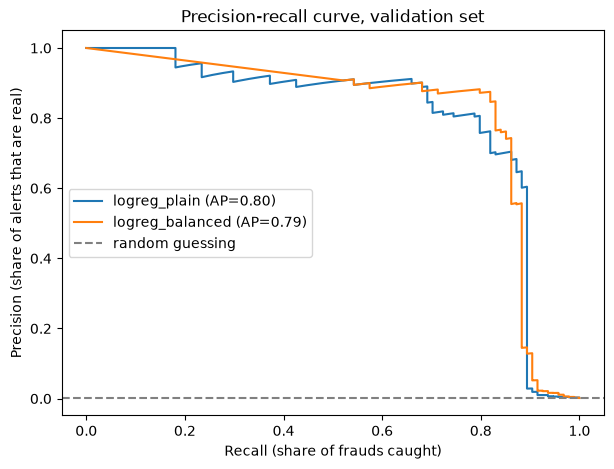

In [7]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7, 5))
for name, m in models.items():
    proba = m.predict_proba(X_val)[:, 1]
    p, r, _ = precision_recall_curve(y_val, proba)
    ax.plot(r, p, label=f"{name} (AP={average_precision_score(y_val, proba):.2f})")
ax.axhline(y_val.mean(), ls="--", color="gray", label="random guessing")
ax.set_xlabel("Recall (share of frauds caught)")
ax.set_ylabel("Precision (share of alerts that are real)")
ax.set_title("Precision-recall curve, validation set")
ax.legend()
plt.show()

In [8]:
rows = []
for t in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    e = evaluate(models["logreg_balanced"], X_val, y_val, threshold=t)
    rows.append({"threshold": t, "precision": e["precision"], "recall": e["recall"],
                 "alerts_raised": e["TP"] + e["FP"]})
pd.DataFrame(rows).round(3)

,threshold,precision,recall,alerts_raised
0,0.10,0.009,0.968,9596
1,0.30,0.027,0.915,3194
2,0.50,0.053,0.904,1589
3,0.70,0.101,0.904,844
4,0.90,0.267,0.883,311
5,0.99,0.583,0.862,139


In [9]:
def precision_recall_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    hits = np.asarray(y_true)[order].sum()
    return hits / k, hits / np.sum(y_true)

scores = models["logreg_balanced"].predict_proba(X_val)[:, 1]
rows = []
for k in [50, 100, 200, 500]:
    p, r = precision_recall_at_k(y_val, scores, k)
    rows.append({"top_k_alerts": k, "precision@k": p, "recall@k": r})
pd.DataFrame(rows).round(3)

,top_k_alerts,precision@k,recall@k
0,50,0.920,0.489
1,100,0.780,0.830
2,200,0.415,0.883
3,500,0.166,0.883
